# Urban Safety — Feature Inspection

Loads and filters the pre-computed segment feature CSV for the five target boroughs. Risk-score calculation has been moved to `02_RiskScore_Calc.ipynb`.

**Input:** `csv/features_all_boroughs_with_location_id_augmented.csv`  
**Output:** filtered feature dataframe for downstream scoring.


## Cell 1 — Imports and config

In [20]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ── File paths ────────────────────────────────────────────────────────────
FEATURES_CACHE = os.path.join('..', 'csv', 'features_all_boroughs_with_location_id_augmented.csv')

# ── Feature columns ───────────────────────────────────────────────────────
FEATURE_COLS = ['lighting', 'visibility', 'connectivity', 'enclosure', 'public_transport_proximity_m', 'dominant_land_use_score']

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.dpi'] = 120


## Cell 2 — Load pre-computed features
Loads the cached feature CSV produced by `00_DataFetching.ipynb` and includes the two OSM-derived enrichment columns.

In [21]:
features = pd.read_csv(FEATURES_CACHE)

# Keep only the five target boroughs
ALLOWED_BOROUGH_NAMES = [
    'City of Westminster, London, UK',
    'London Borough of Islington, London, UK',
    'London Borough of Hackney, London, UK',
    'London Borough of Tower Hamlets, London, UK',
    'London Borough of Southwark, London, UK',
]
if 'borough' in features.columns:
    before = len(features)
    features = features[features['borough'].isin(ALLOWED_BOROUGH_NAMES)].reset_index(drop=True)
    after = len(features)
    print(f'\u2713 Loaded {after:,} segments from {FEATURES_CACHE} (filtered from {before:,})')
    print(f'  Boroughs : {features["borough"].nunique()}')
    print(features['borough'].value_counts().to_string())
else:
    print(f'\u2713 Loaded {len(features):,} segments from {FEATURES_CACHE} (no borough column to filter)')

print('Risk-score calculation continues in 02_RiskScore_Calc.ipynb.')

✓ Loaded 35,978 segments from ..\csv\features_all_boroughs_with_location_id_augmented.csv (filtered from 35,978)
  Boroughs : 5
borough
London Borough of Southwark, London, UK        9757
London Borough of Tower Hamlets, London, UK    7618
City of Westminster, London, UK                7558
London Borough of Hackney, London, UK          5863
London Borough of Islington, London, UK        5182
Risk-score calculation continues in 02_RiskScore_Calc.ipynb.


Rows: 35,978
Columns: 12


,count,mean,std,min,25%,50%,75%,max
lighting,35978.0,2.069807,5.956091,0.0000,0.000000,0.000000,1.233826,163.390439
visibility,35978.0,0.703532,0.115325,0.2468,0.646200,0.721200,0.777100,1.000000
connectivity,35978.0,10.431430,2.325652,3.0000,8.000000,11.000000,12.000000,17.000000
enclosure,35978.0,0.286703,0.149928,0.0000,0.194592,0.272238,0.366869,1.136015
public_transport_proximity_m,35978.0,110.696102,75.332217,0.4500,53.940000,95.435000,153.990000,541.240000
dominant_land_use_score,35903.0,0.309621,0.192390,0.0000,0.152100,0.306300,0.449400,1.000000


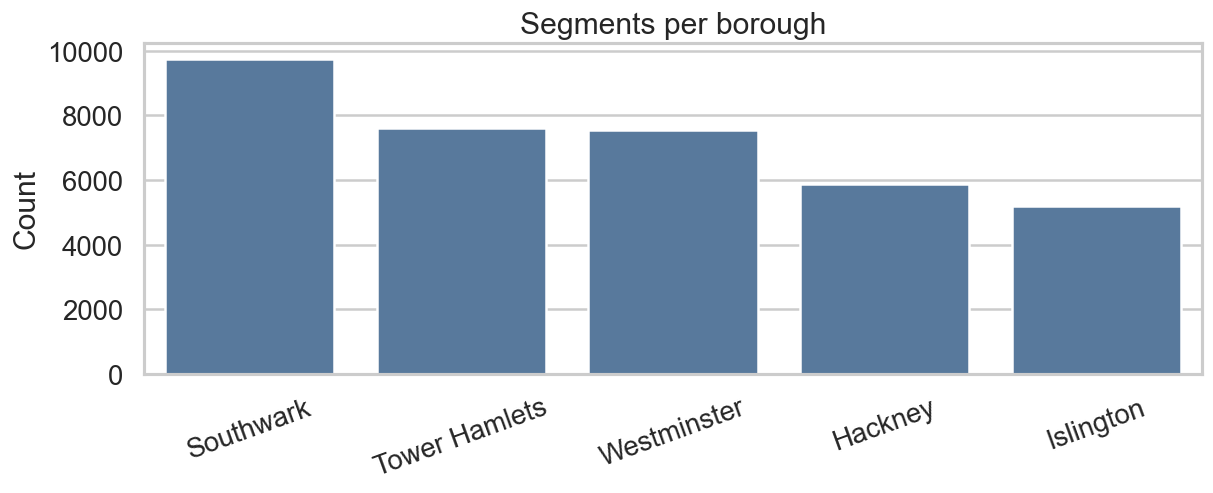

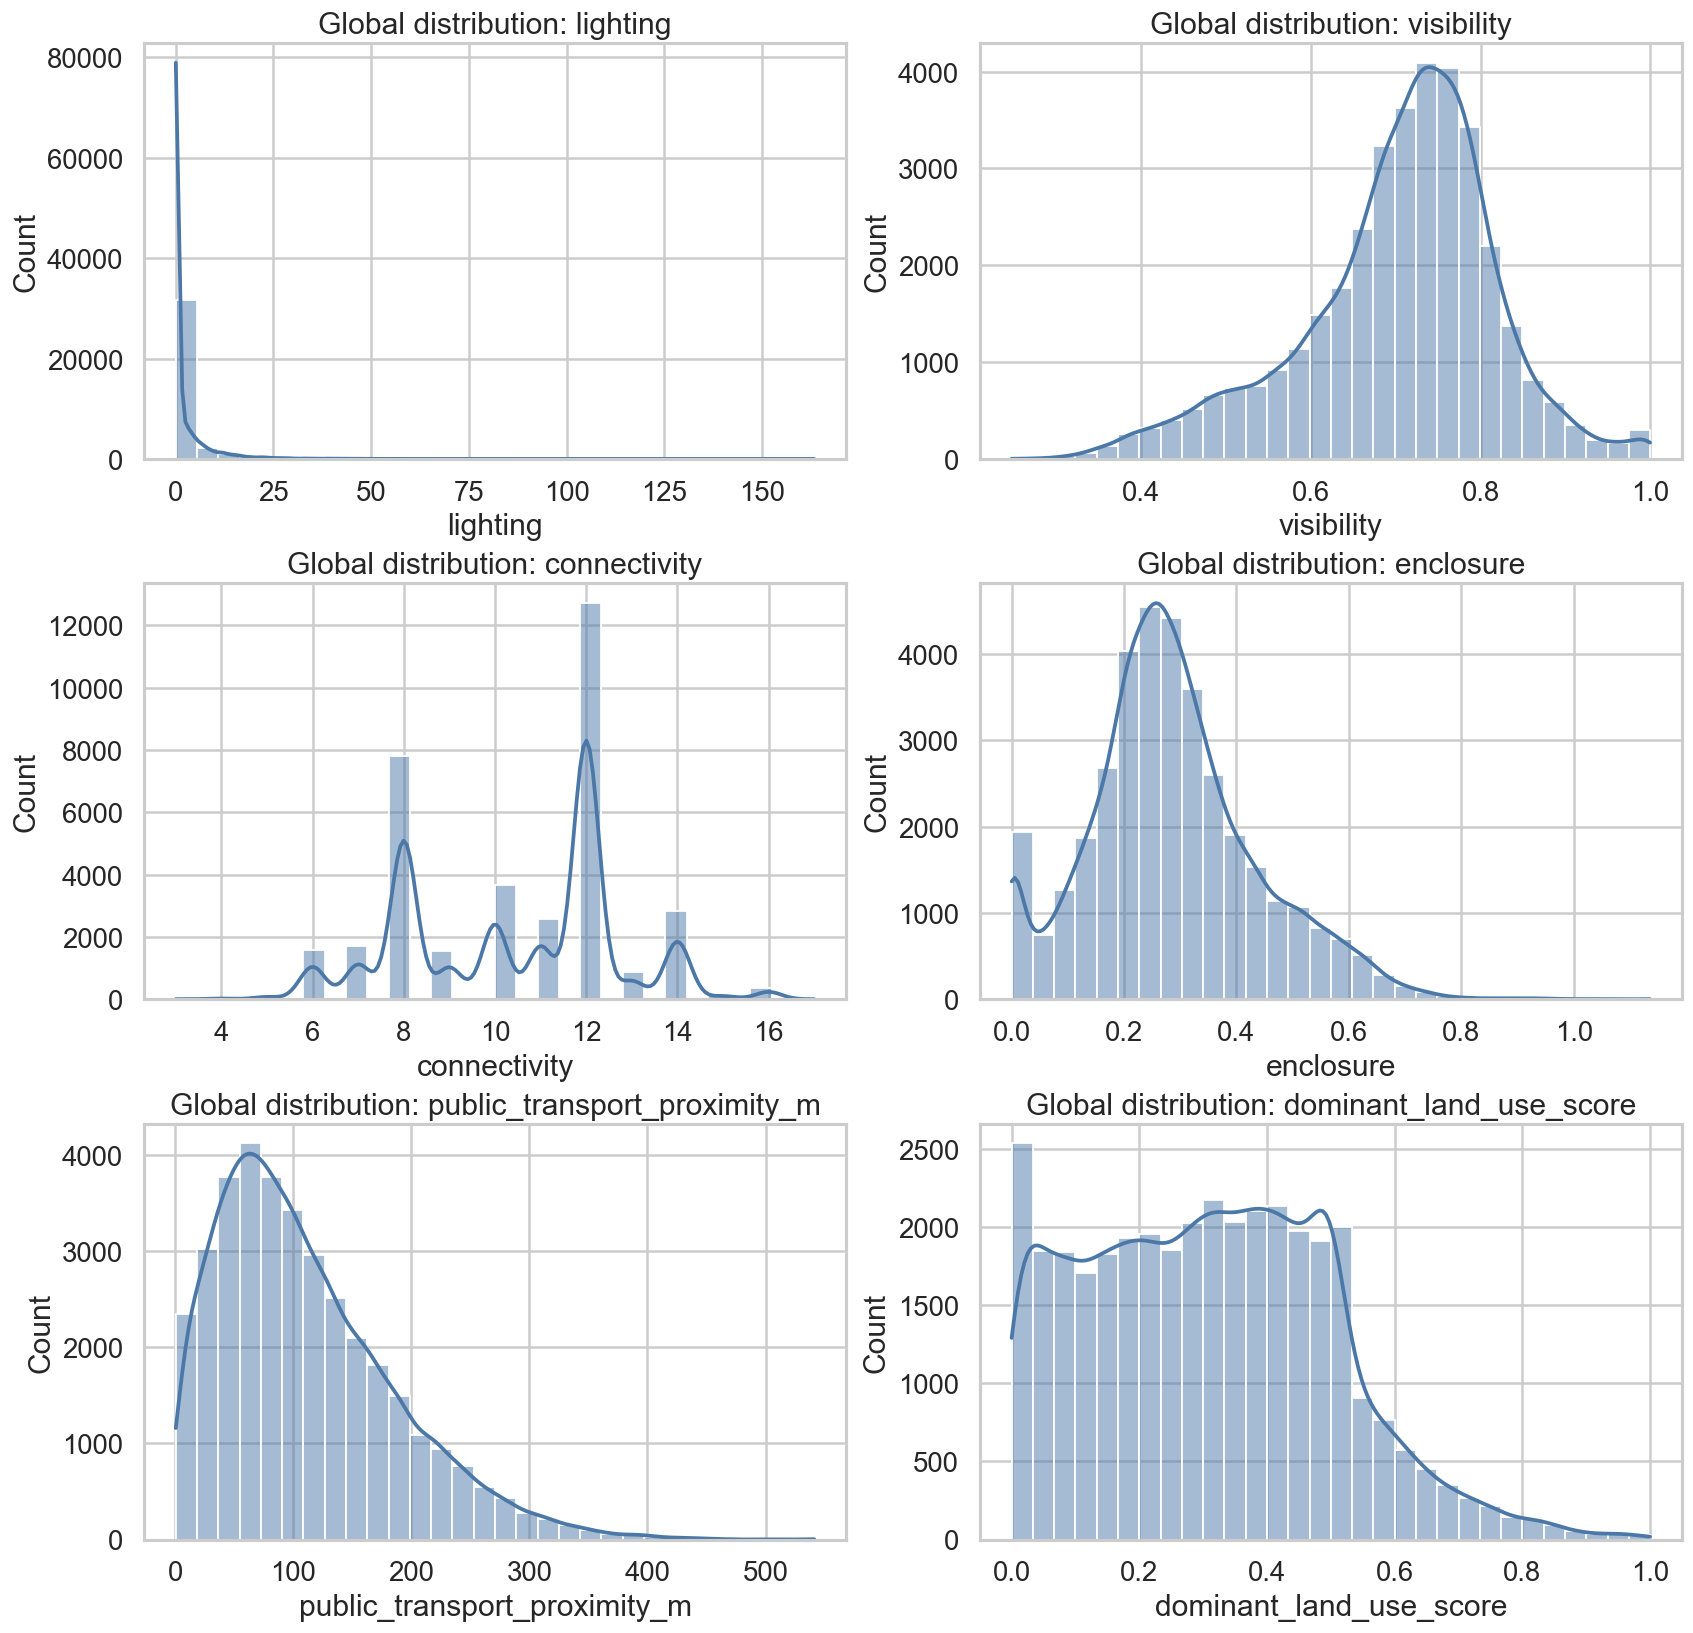

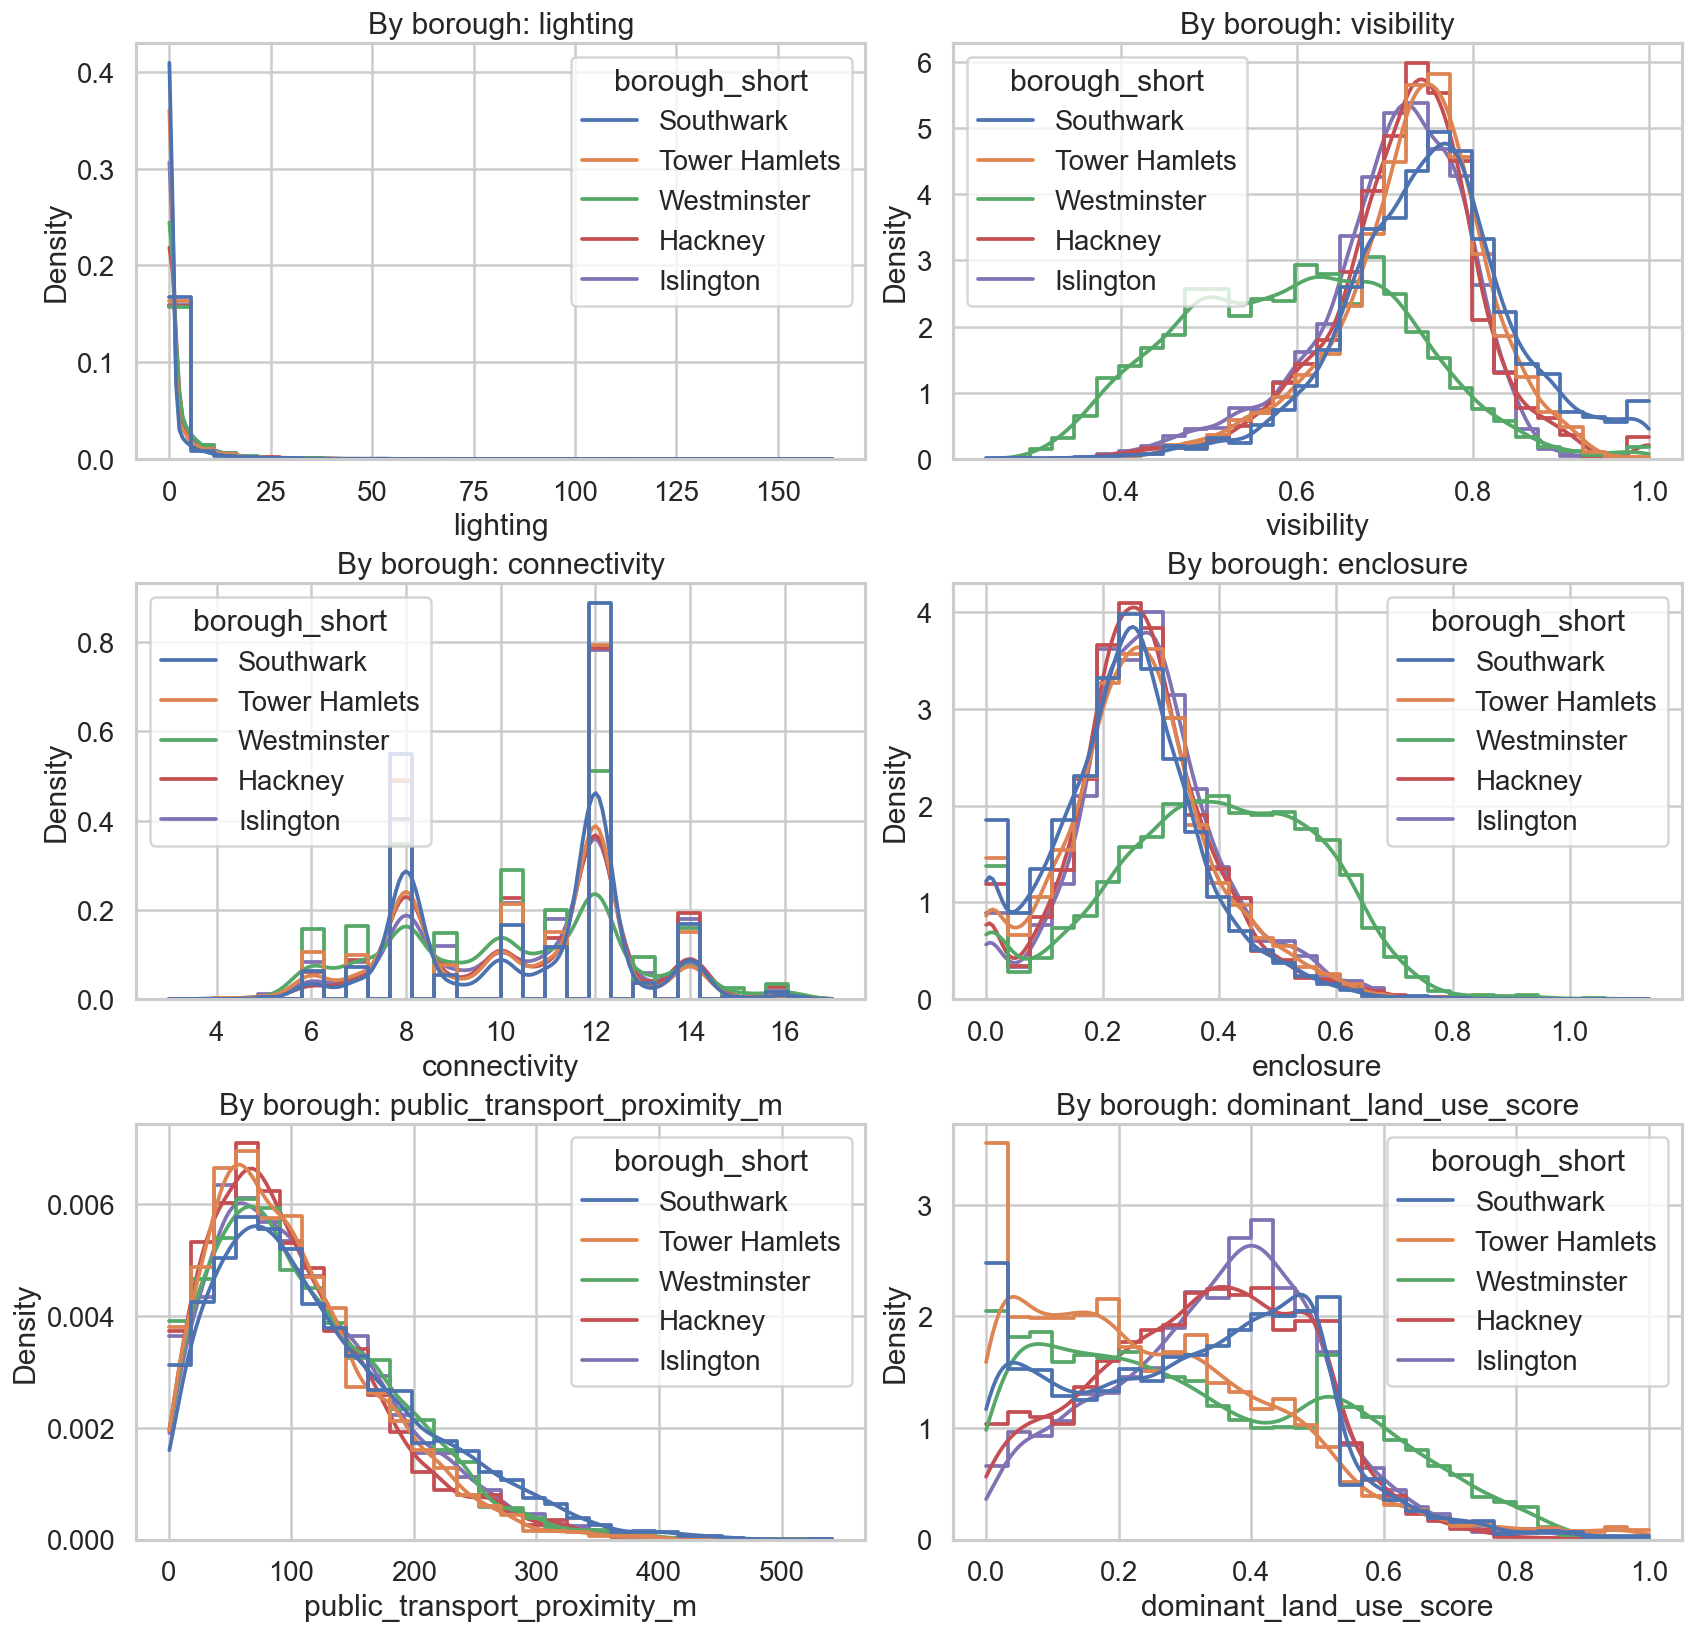

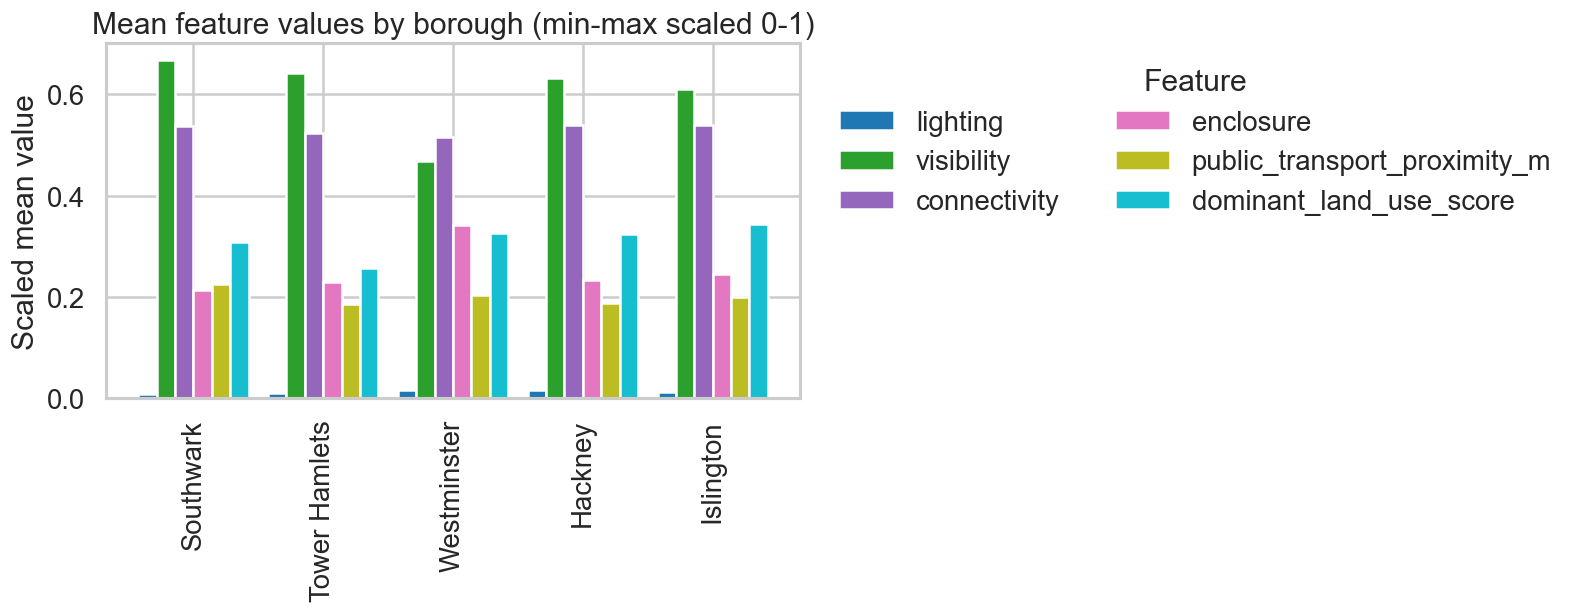

Risk-score calculation continues in 02_RiskScore_Calc.ipynb.


In [22]:
# Quick feature inspection plots
plot_df = features.copy()
plot_feature_cols = [col for col in FEATURE_COLS if col in plot_df.columns]
borough_labels = {
    'City of Westminster, London, UK': 'Westminster',
    'London Borough of Islington, London, UK': 'Islington',
    'London Borough of Hackney, London, UK': 'Hackney',
    'London Borough of Tower Hamlets, London, UK': 'Tower Hamlets',
    'London Borough of Southwark, London, UK': 'Southwark',
}
borough_order = plot_df['borough'].value_counts().index.tolist() if 'borough' in plot_df.columns else []

print(f'Rows: {len(plot_df):,}')
print(f'Columns: {len(plot_df.columns):,}')
if plot_feature_cols:
    display(plot_df[plot_feature_cols].describe().T)

if borough_order:
    fig, ax = plt.subplots(figsize=(10, 4), constrained_layout=True)
    borough_counts = plot_df['borough'].value_counts().reindex(borough_order)
    borough_counts.index = [borough_labels.get(name, name) for name in borough_counts.index]
    sns.barplot(x=borough_counts.index, y=borough_counts.values, ax=ax, color='#4C78A8')
    ax.set_title('Segments per borough')
    ax.set_xlabel('')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=20)
    plt.show()

if plot_feature_cols:
    n_cols = 2
    n_rows = (len(plot_feature_cols) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4.5 * n_rows), constrained_layout=True)
    axes = axes.flatten()

    for ax, col in zip(axes, plot_feature_cols):
        enable_kde = plot_df[col].dropna().nunique() > 1
        sns.histplot(plot_df[col], bins=30, kde=enable_kde, ax=ax, color='#4C78A8')
        ax.set_title(f'Global distribution: {col}')
        ax.set_xlabel(col)
        ax.set_ylabel('Count')

    for ax in axes[len(plot_feature_cols):]:
        ax.axis('off')

    plt.show()

if borough_order and plot_feature_cols:
    plot_df['borough_short'] = plot_df['borough'].map(borough_labels).fillna(plot_df['borough'])
    hue_order = [borough_labels.get(name, name) for name in borough_order]

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4.5 * n_rows), constrained_layout=True)
    axes = axes.flatten()

    for ax, col in zip(axes, plot_feature_cols):
        group_sizes = plot_df.groupby('borough_short')[col].apply(lambda series: series.dropna().nunique())
        enable_kde = bool((group_sizes > 1).all())
        sns.histplot(
            data=plot_df,
            x=col,
            hue='borough_short',
            hue_order=hue_order,
            bins=30,
            stat='density',
            common_norm=False,
            element='step',
            fill=False,
            kde=enable_kde,
            ax=ax,
        )
        ax.set_title(f'By borough: {col}')
        ax.set_xlabel(col)
        ax.set_ylabel('Density')

    for ax in axes[len(plot_feature_cols):]:
        ax.axis('off')

    plt.show()

    scaled_df = plot_df.copy()
    for col in plot_feature_cols:
        series = scaled_df[col].astype(float)
        col_min = series.min()
        col_max = series.max()
        scaled_df[col] = 0.0 if col_max == col_min else (series - col_min) / (col_max - col_min)

    borough_means_scaled = scaled_df.groupby('borough_short')[plot_feature_cols].mean().reindex(hue_order)
    fig, ax = plt.subplots(figsize=(13, 5), constrained_layout=True)
    borough_means_scaled.plot(kind='bar', ax=ax, width=0.85, colormap='tab10')
    ax.set_title('Mean feature values by borough (min-max scaled 0-1)')
    ax.set_xlabel('')
    ax.set_ylabel('Scaled mean value')
    ax.legend(title='Feature', ncol=2, frameon=False, bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.show()

print('Risk-score calculation continues in 02_RiskScore_Calc.ipynb.')